In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Cell 2: Load and Filter Dataset
df = pd.read_csv("5g_nidd.csv")

# Keep only UDP and TCP related attack types
df = df[df['Attack Type'].isin(['UDPFlood', 'UDPScan',
                               'HTTPFlood', 'SlowrateDoS', 'SYNFlood', 'SYNScan', 'TCPConnectScan',
                               'Benign'])]

# Separate features and labels
X = df.drop(columns=['Attack Type']).values
y = df['Attack Type'].values

/var/folders/45/0lfy6jf14g3cptljv3x_x53r0000gn/T/ipykernel_48160/4169188943.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("5g_nidd.csv")


In [3]:
# X preprocessing
scaler = MinMaxScaler()

# Keep only columns with numeric dtype in X
float_cols = [i for i, col in enumerate(df.drop(columns=['Attack Type']).columns) if df[col].dtype != str and df[col].dtype != 'object']
X_numeric = X[:, float_cols]

X_scaled = scaler.fit_transform(X_numeric)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)


In [4]:
# Calculate importance of features using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Use the scaled features and binary labels
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

X_udp_only = X_scaled[(y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan')]  # Use only TCP for feature importance
y_udp_only = y[(y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan')]
rf.fit(X_udp_only, y_udp_only)

importances = rf.feature_importances_

# Get feature names from df using float_cols
feature_names = df.drop(columns=['Attack Type']).columns[float_cols]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Id': range(len(feature_names)),
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Keep only top 32 features by importance
top_features = feature_importance_df['Id'].iloc[:32].tolist()

print("Top 32 features:", top_features)
X_processed = X_scaled[:, top_features]

print(X_processed.shape)

    Id     Feature  Importance
41  41      TcpRtt    0.109292
35  35      SrcWin    0.101682
43  43      AckDat    0.096073
0    0  Unnamed: 0    0.077393
1    1         Seq    0.065148
36  36      DstWin    0.061798
21  21  sMeanPktSz    0.056094
17  17    TotBytes    0.042459
18  18    SrcBytes    0.038606
20  20      Offset    0.036696
22  22  dMeanPktSz    0.036019
19  19    DstBytes    0.031271
10  10        sTtl    0.028692
11  11        dTtl    0.025500
40  40  DstTCPBase    0.025025
42  42      SynAck    0.023240
12  12       sHops    0.021752
13  13       dHops    0.018518
25  25     DstLoad    0.015829
23  23        Load    0.014652
16  16     DstPkts    0.010031
32  32        Rate    0.007495
33  33     SrcRate    0.006893
14  14     TotPkts    0.006527
5    5         Sum    0.006051
3    3     RunTime    0.005830
24  24     SrcLoad    0.005687
6    6         Min    0.004803
34  34     DstRate    0.004795
15  15     SrcPkts    0.004172
4    4        Mean    0.003604
2    2  

In [5]:
# Y preprocessing
y_processed = np.where(y == 'Benign', 0, 1)

In [6]:
# Cell 4: Define the MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [7]:
def meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred_train = model(x_meta_train)
    loss_train = loss_fn(y_pred_train, y_meta_train)

    # Forward pass on meta-test
    y_pred_test = model(x_meta_test)
    loss_test = loss_fn(y_pred_test, y_meta_test)

    # Combined loss
    loss = alpha * loss_train + (1 - alpha) * loss_test

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [8]:
def normal_train_step(model, x_train, y_train, optimizer):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [9]:
# Get indices for each class in train
benign_index = np.where(y == 'Benign')[0]
udp_index = np.where((y == 'UDPFlood') | (y == 'UDPScan'))[0]
tcp_index = np.where((y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan'))[0]

print("Benign size:", len(benign_index))
print("UDP size:", len(udp_index))
print("TCP size:", len(tcp_index))

# Split indices into train and test sets
train_udp_index = np.random.choice(udp_index, int(0.8 * len(udp_index)), replace=False)
test_udp_index = np.setdiff1d(udp_index, train_udp_index)

Benign size: 477737
UDP size: 473246
TCP size: 263752


In [10]:
benign_index = np.where(y == 'Benign')[0]
tcp_index = np.where((y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan'))[0]
print(f"Comaparing TCP dataset with Benign dataset: {len(tcp_index) / len(benign_index) * 100:.2f}%")

# Keep only TCP and Benign for folding
percent_tcp_samples = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
# 0.1%, 0.2%, 0.5%, 1%, 2%, 5% of Benign dataset

number_tcp_samples = [int(len(benign_index) * i) for i in percent_tcp_samples]
print(f"Number of TCP samples: {number_tcp_samples}")

f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

for number_samples in number_tcp_samples:
    repetition_f1_scores = []
    repetition_precisions = []
    repetition_recalls = []
    print(f"Running for number of TCP samples: {number_samples}")

    # Take a random sample of TCP samples from X_tcp_only_processed
    rng = np.random.default_rng(seed=number_samples)
    tcp_sample_index = rng.choice(tcp_index, size=number_samples, replace=False)
    combined_index = np.concatenate([tcp_sample_index, benign_index])
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []
    
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        train_index = combined_index[train]
        test_index = combined_index[test]
        
        # Train set: 
        x_train = torch.tensor(X_processed[train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[train_index], dtype=torch.float32).unsqueeze(1)

        # Evaluation set:
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)
        
        # Count number of 0 and 1 in y_train
        train_num_zeros = (y_train == 0).sum().item()
        train_num_ones = (y_train == 1).sum().item()
        print(f"y_train: {train_num_zeros} zeros, {train_num_ones} ones")

        # Count number of 0 and 1 in y_test
        test_num_zeros = (y_test == 0).sum().item()
        test_num_ones = (y_test == 1).sum().item()
        print(f"y_test: {test_num_zeros} zeros, {test_num_ones} ones")

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred, zero_division=0)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred, zero_division=0)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

Comaparing TCP dataset with Benign dataset: 55.21%
Number of TCP samples: [477, 955, 2388, 4777, 9554, 23886]
Running for number of TCP samples: 477
y_train: 382190 zeros, 381 ones
y_test: 95547 zeros, 96 ones
y_train: 382189 zeros, 382 ones
y_test: 95548 zeros, 95 ones
y_train: 382188 zeros, 383 ones
y_test: 95549 zeros, 94 ones
y_train: 382182 zeros, 389 ones
y_test: 95555 zeros, 88 ones
y_train: 382199 zeros, 373 ones
y_test: 95538 zeros, 104 ones
Running for number of TCP samples: 955
y_train: 382198 zeros, 755 ones
y_test: 95539 zeros, 200 ones
y_train: 382173 zeros, 780 ones
y_test: 95564 zeros, 175 ones
y_train: 382183 zeros, 771 ones
y_test: 95554 zeros, 184 ones
y_train: 382186 zeros, 768 ones
y_test: 95551 zeros, 187 ones
y_train: 382208 zeros, 746 ones
y_test: 95529 zeros, 209 ones
Running for number of TCP samples: 2388
y_train: 382223 zeros, 1877 ones
y_test: 95514 zeros, 511 ones
y_train: 382180 zeros, 1920 ones
y_test: 95557 zeros, 468 ones
y_train: 382192 zeros, 1908 on

F1 Scores:
0.8044 ± 0.1214
0.9222 ± 0.0719
0.9725 ± 0.0100
0.9837 ± 0.0033
0.9881 ± 0.0026
0.9951 ± 0.0004
Precisions:
0.9457 ± 0.0287
0.9565 ± 0.0379
0.9825 ± 0.0035
0.9890 ± 0.0037
0.9912 ± 0.0045
0.9960 ± 0.0008
Recalls:
0.7130 ± 0.1522
0.8927 ± 0.0991
0.9627 ± 0.0165
0.9783 ± 0.0049
0.9851 ± 0.0025
0.9943 ± 0.0007


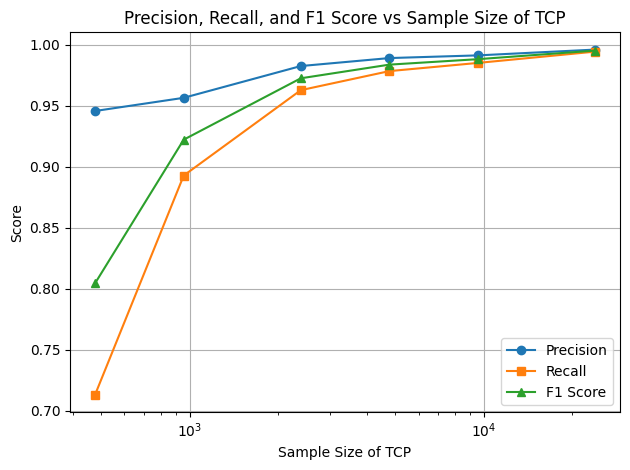

In [11]:
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = number_tcp_samples

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xlabel('Sample Size of TCP')
plt.ylabel('Score')
plt.xscale('log')
plt.title('Precision, Recall, and F1 Score vs Sample Size of TCP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
samples = number_tcp_samples[3]
rng = np.random.default_rng(seed=samples)
tcp_index = np.where((y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan'))[0]
random_selected_tcp_index = rng.choice(tcp_index, size=samples, replace=False)
print(len(random_selected_tcp_index), "samples of TCP selected.")

# Update tcp_index to the selected samples
tcp_index = random_selected_tcp_index

4777 samples of TCP selected.


In [13]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(tcp_index)
    rng.shuffle(train_udp_index)
    rng.shuffle(test_udp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, tcp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_tcp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_tcp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_tcp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Count number of 0 and 1 in y_meta_train
        meta_train_num_zeros = (y_meta_train == 0).sum().item()
        meta_train_num_ones = (y_meta_train == 1).sum().item()
        print(f"y_meta_train: {meta_train_num_zeros} zeros, {meta_train_num_ones} ones")

        # Meta-test: len_meta_test samples from UDP + 20% Benign
        meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Count number of 0 and 1 in y_meta_test
        meta_test_num_zeros = (y_meta_test == 0).sum().item()
        meta_test_num_ones = (y_meta_test == 1).sum().item()
        print(f"y_meta_test: {meta_test_num_zeros} zeros, {meta_test_num_ones} ones")

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
482514 samples in combined index.
y_meta_train: 305720 zeros, 3861 ones
y_meta_test: 76430 zeros, 0 ones
y_meta_train: 305748 zeros, 3825 ones
y_meta_test: 76438 zeros, 0 ones
y_meta_train: 305736 zeros, 3840 ones
y_meta_test: 76435 zeros, 0 ones
y_meta_train: 305747 zeros, 3827 ones
y_meta_test: 76437 zeros, 0 ones
y_meta_train: 305805 zeros, 3755 ones
y_meta_test: 76452 zeros, 0 ones
F1 Score: 0.6510 ± 0.0071
Running for len_meta_test: 1
482514 samples in combined index.
y_meta_train: 305720 zeros, 3861 ones
y_meta_test: 76430 zeros, 1 ones
y_meta_train: 305748 zeros, 3825 ones
y_meta_test: 76438 zeros, 1 ones
y_meta_train: 305736 zeros, 3840 ones
y_meta_test: 76435 zeros, 1 ones
y_meta_train: 305747 zeros, 3827 ones
y_meta_test: 76437 zeros, 1 ones
y_meta_train: 305805 zeros, 3755 ones
y_meta_test: 76452 zeros, 1 ones
F1 Score: 0.6540 ± 0.0048
Running for len_meta_test: 10
482514 samples in combined index.
y_meta_train: 305720 zeros, 3861 ones
y_meta_tes

F1 Scores:
0.6510 ± 0.0071
0.6540 ± 0.0048
0.7308 ± 0.0218
0.9132 ± 0.0175
0.9784 ± 0.0101
0.9875 ± 0.0038
Precisions:
0.9998 ± 0.0004
0.9998 ± 0.0004
1.0000 ± 0.0000
0.9996 ± 0.0003
0.9999 ± 0.0002
0.9997 ± 0.0004
Recalls:
0.4826 ± 0.0077
0.4859 ± 0.0054
0.5762 ± 0.0266
0.8410 ± 0.0298
0.9581 ± 0.0192
0.9756 ± 0.0072


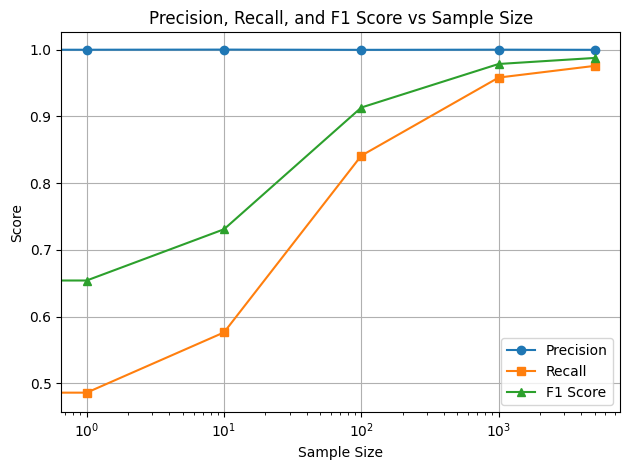

In [14]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different alphas
for alpha in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    len_meta_test = 1000
    print(f"Running for alpha: {alpha}")
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=int(alpha * 1000))  # Use alpha to seed the RNG
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, tcp_index])
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_tcp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_tcp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]

        # Meta-train: all TCP + 80% Benign
        meta_train_index = np.concatenate([train_tcp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Meta-test: len_meta_test samples from UDP + 20% Benign
        meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=alpha)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for alpha: 0.0
F1 Score: 0.6592 ± 0.0064
Running for alpha: 0.1
F1 Score: 0.9556 ± 0.0054
Running for alpha: 0.2
F1 Score: 0.9678 ± 0.0074
Running for alpha: 0.3
F1 Score: 0.9654 ± 0.0077
Running for alpha: 0.4
F1 Score: 0.9732 ± 0.0059
Running for alpha: 0.5
F1 Score: 0.9754 ± 0.0061
Running for alpha: 0.6
F1 Score: 0.9774 ± 0.0081
Running for alpha: 0.7
F1 Score: 0.9750 ± 0.0073
Running for alpha: 0.8
F1 Score: 0.9712 ± 0.0103
Running for alpha: 0.9
F1 Score: 0.9608 ± 0.0098
Running for alpha: 1.0
F1 Score: 0.6545 ± 0.0095


F1 Scores:
0.6592 ± 0.0064
0.9556 ± 0.0054
0.9678 ± 0.0074
0.9654 ± 0.0077
0.9732 ± 0.0059
0.9754 ± 0.0061
0.9774 ± 0.0081
0.9750 ± 0.0073
0.9712 ± 0.0103
0.9608 ± 0.0098
0.6545 ± 0.0095
Precisions:
0.9998 ± 0.0004
0.9998 ± 0.0003
0.9999 ± 0.0002
0.9999 ± 0.0002
0.9998 ± 0.0003
0.9998 ± 0.0003
0.9997 ± 0.0004
1.0000 ± 0.0000
0.9999 ± 0.0002
0.9993 ± 0.0008
1.0000 ± 0.0000
Recalls:
0.4917 ± 0.0071
0.9152 ± 0.0098
0.9377 ± 0.0138
0.9333 ± 0.0144
0.9480 ± 0.0111
0.9522 ± 0.0116
0.9562 ± 0.0154
0.9513 ± 0.0137
0.9442 ± 0.0194
0.9253 ± 0.0181
0.4865 ± 0.0105


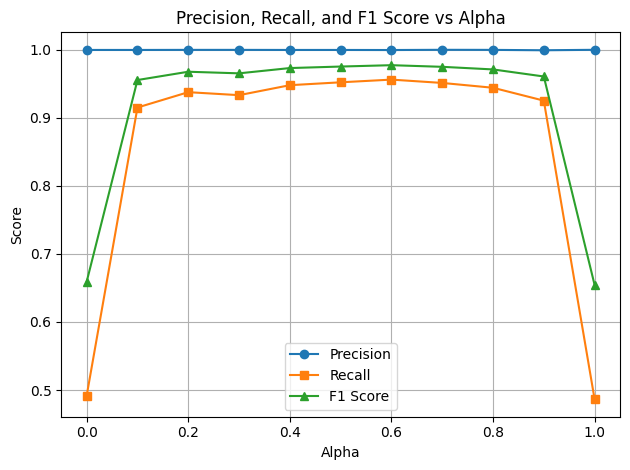

In [16]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
f1_scores_tcp = []
f1_scores_std_tcp = []
precisions_tcp = []
precisions_std_tcp = []
recalls_tcp = []
recalls_std_tcp = []

f1_scores_tcp_udp = []
f1_scores_std_tcp_udp = []
precisions_tcp_udp = []
precisions_std_tcp_udp = []
recalls_tcp_udp = []
recalls_std_tcp_udp = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_udp_index)
    rng.shuffle(test_udp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores_tcp = []
    fold_precisions_tcp = []
    fold_recalls_tcp = []

    fold_f1_scores_tcp_udp = []
    fold_precisions_tcp_udp = []
    fold_recalls_tcp_udp = []

    combined_index = np.concatenate([benign_index, tcp_index])
    print(len(combined_index), "samples in combined index.")
    print("Number of ones in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 1))
    print("Number of zeros in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 0))
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = np.intersect1d(train_index, benign_index)
        train_tcp_index = np.intersect1d(train_index, tcp_index)
        test_benign_index = np.intersect1d(test_index, benign_index)
        test_tcp_index = np.intersect1d(test_index, tcp_index)

        # Split into 50% and 50%    
        len_train_tcp_50 = int(0.50 * len(train_tcp_index))
        
        # Split into 33%, 33% and 34%    
        len_train_benign_33 = int(0.33 * len(train_benign_index))
        len_train_benign_66 = int(0.66 * len(train_benign_index))

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        #--------------------------------- Training with TCP only ---------------------------------------#
        # Train: 50% TCP + 50% Benign
        tcp_train_index = np.concatenate([train_tcp_index[:len_train_tcp_50], train_benign_index[:len_train_benign_33]])
        x_train = torch.tensor(X_processed[tcp_train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[tcp_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_train_index]:", np.sum(y_processed[tcp_train_index] == 1))
        print("Number of zeros in y_processed[tcp_train_index]:", np.sum(y_processed[tcp_train_index] == 0))

        # Training with TCP only
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation with TCP only
        with torch.no_grad():
            tcp_test_index = np.concatenate([test_benign_index[:1000], test_tcp_index[:1000]])
            x_test = torch.tensor(X_processed[tcp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[tcp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[tcp_test_index]:", np.sum(y_processed[tcp_test_index] == 1))
            print("Number of zeros in y_processed[tcp_test_index]:", np.sum(y_processed[tcp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred, zero_division=0)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred, zero_division=0)

            fold_f1_scores_tcp.append(score)
            fold_precisions_tcp.append(precision)
            fold_recalls_tcp.append(recall)


        #--------------------------------- Training with TCP and UDP ---------------------------------------#
        # Meta-train: 50% TCP + 25% Benign
        tcp_udp_meta_train_index = np.concatenate([train_tcp_index[len_train_tcp_50:], train_benign_index[len_train_benign_33:len_train_benign_66]])
        x_meta_train = torch.tensor(X_processed[tcp_udp_meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[tcp_udp_meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_udp_meta_train_index]:", np.sum(y_processed[tcp_udp_meta_train_index] == 1))
        print("Number of zeros in y_processed[tcp_udp_meta_train_index]:", np.sum(y_processed[tcp_udp_meta_train_index] == 0))

        # Meta-test: len_meta_test samples from UDP and 15% Benign
        tcp_udp_meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_index[len_train_benign_66:]
        ])
        x_meta_test = torch.tensor(X_processed[tcp_udp_meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[tcp_udp_meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_udp_meta_test_index]:", np.sum(y_processed[tcp_udp_meta_test_index] == 1))
        print("Number of zeros in y_processed[tcp_udp_meta_test_index]:", np.sum(y_processed[tcp_udp_meta_test_index] == 0))

        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)
            
        # Evaluation
        with torch.no_grad():
            tcp_udp_test_index = np.concatenate([test_benign_index[:2000], test_udp_index[:1000], test_tcp_index[:1000]])
            x_test= torch.tensor(X_processed[tcp_udp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[tcp_udp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[tcp_udp_test_index]:", np.sum(y_processed[tcp_udp_test_index] == 1))
            print("Number of zeros in y_processed[tcp_udp_test_index]:", np.sum(y_processed[tcp_udp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred, zero_division=0)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred, zero_division=0)

            fold_f1_scores_tcp_udp.append(score)
            fold_precisions_tcp_udp.append(precision)
            fold_recalls_tcp_udp.append(recall)
        

    f1_scores_tcp.append(np.mean(fold_f1_scores_tcp))
    precisions_tcp.append(np.mean(fold_precisions_tcp))
    recalls_tcp.append(np.mean(fold_recalls_tcp))
    f1_scores_std_tcp.append(np.std(fold_f1_scores_tcp))
    precisions_std_tcp.append(np.std(fold_precisions_tcp))
    recalls_std_tcp.append(np.std(fold_recalls_tcp))

    f1_scores_tcp_udp.append(np.mean(fold_f1_scores_tcp_udp))
    precisions_tcp_udp.append(np.mean(fold_precisions_tcp_udp))
    recalls_tcp_udp.append(np.mean(fold_recalls_tcp_udp))
    f1_scores_std_tcp_udp.append(np.std(fold_f1_scores_tcp_udp))
    precisions_std_tcp_udp.append(np.std(fold_precisions_tcp_udp))
    recalls_std_tcp_udp.append(np.std(fold_recalls_tcp_udp))

    print(f"F1 Score of M1 (UDP only): {f1_scores_tcp[-1]:.4f} ± {f1_scores_std_tcp[-1]:.4f}")
    print(f"F1 Score of M2 (UDP + TCP): {f1_scores_tcp_udp[-1]:.4f} ± {f1_scores_std_tcp_udp[-1]:.4f}")

Running for len_meta_test: 0
482514 samples in combined index.
Number of ones in y_processed[combined_index]: 4777
Number of zeros in y_processed[combined_index]: 477737
Number of ones in y_processed[tcp_train_index]: 1930
Number of zeros in y_processed[tcp_train_index]: 126109
Number of ones in y_processed[tcp_test_index]: 916
Number of zeros in y_processed[tcp_test_index]: 1000
Number of ones in y_processed[tcp_udp_meta_train_index]: 1931
Number of zeros in y_processed[tcp_udp_meta_train_index]: 126110
Number of ones in y_processed[tcp_udp_meta_test_index]: 0
Number of zeros in y_processed[tcp_udp_meta_test_index]: 129931
Number of ones in y_processed[tcp_udp_test_index]: 1916
Number of zeros in y_processed[tcp_udp_test_index]: 2000
Number of ones in y_processed[tcp_train_index]: 1912
Number of zeros in y_processed[tcp_train_index]: 126121
Number of ones in y_processed[tcp_test_index]: 952
Number of zeros in y_processed[tcp_test_index]: 1000
Number of ones in y_processed[tcp_udp_meta

F1 Scores of M1 (UDP only):
F1 Scores:
0.9684 ± 0.0016
0.9604 ± 0.0119
0.9652 ± 0.0045
0.9647 ± 0.0089
0.9714 ± 0.0058
0.9610 ± 0.0080
Precisions:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Recalls:
0.9387 ± 0.0031
0.9240 ± 0.0222
0.9328 ± 0.0084
0.9319 ± 0.0165
0.9444 ± 0.0109
0.9250 ± 0.0148
F1 Scores of M2 (TCP + UDP):
F1 Scores:
0.6273 ± 0.0094
0.6262 ± 0.0120
0.7180 ± 0.0542
0.9426 ± 0.0116
0.9712 ± 0.0109
0.9767 ± 0.0045
Precisions:
0.9998 ± 0.0005
0.9993 ± 0.0009
0.9998 ± 0.0004
0.9997 ± 0.0005
0.9998 ± 0.0003
0.9995 ± 0.0006
Recalls:
0.4571 ± 0.0100
0.4561 ± 0.0127
0.5628 ± 0.0652
0.8919 ± 0.0209
0.9444 ± 0.0203
0.9550 ± 0.0087


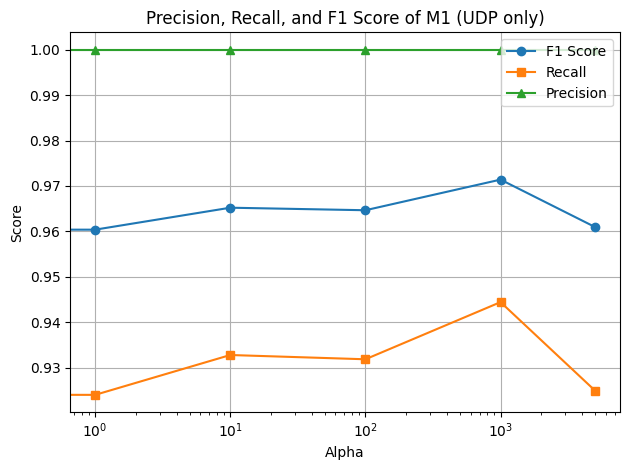

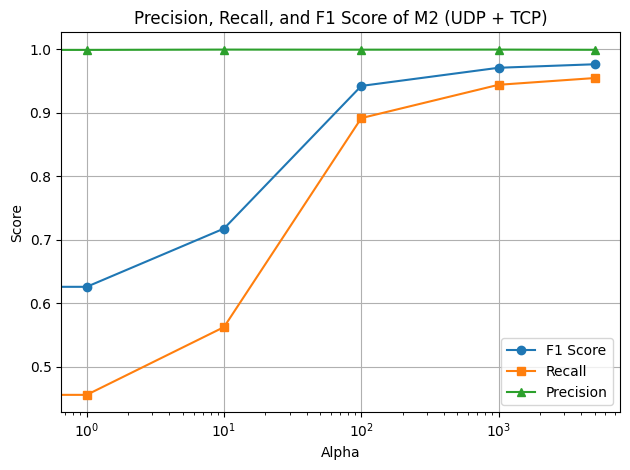

In [18]:
# Visualization
print("F1 Scores of M1 (UDP only):")
print("F1 Scores:")
for i in range(len(f1_scores_tcp)):
    print(f"{f1_scores_tcp[i]:.4f} ± {f1_scores_std_tcp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_tcp)):
    print(f"{precisions_tcp[i]:.4f} ± {precisions_std_tcp[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_tcp)):
    print(f"{recalls_tcp[i]:.4f} ± {recalls_std_tcp[i]:.4f}")

print("F1 Scores of M2 (TCP + UDP):")
print("F1 Scores:")
for i in range(len(f1_scores_tcp_udp)):
    print(f"{f1_scores_tcp_udp[i]:.4f} ± {f1_scores_std_tcp_udp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_tcp_udp)):
    print(f"{precisions_tcp_udp[i]:.4f} ± {precisions_std_tcp_udp[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_tcp_udp)):
    print(f"{recalls_tcp_udp[i]:.4f} ± {recalls_std_tcp_udp[i]:.4f}")

x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, f1_scores_tcp, marker='o', label='F1 Score')
plt.plot(x, recalls_tcp, marker='s', label='Recall')
plt.plot(x, precisions_tcp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M1 (UDP only)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.plot(x, f1_scores_tcp_udp, marker='o', label='F1 Score')
plt.plot(x, recalls_tcp_udp, marker='s', label='Recall')
plt.plot(x, precisions_tcp_udp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M2 (UDP + TCP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()